In [45]:
%matplotlib widget

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [47]:
spectrum_1 = pd.read_csv("Spectrum1s_1_gas_exp.csv")
spectrum_2 = pd.read_csv("Spectrum1s_2_gas_exp.csv")
spectrum_3 = pd.read_csv("Spectrum1s_3_gas_exp.csv")
spectrum_4 = pd.read_csv("Spectrum1s_4_gas_exp.csv")

In [48]:
spectrum_1

,Name,Flux,Error_flux
0,Hgamma,4.188488,0.052823
1,Hbeta,9.863594,0.090706
2,Halpha,32.963523,0.085275
3,[SII]6731_d1,0.985061,0.044450
4,[SII]6731_d2,3.913014,0.052558
5,HeII4687,0.107944,0.003131
6,HeI5876,1.310977,0.011729
7,[OIII]4959,4.346962,0.091945
8,[OIII]5007,13.040887,0.091945
9,[OI]6300,0.323034,0.004232


In [49]:
np.log(55.02/42.46)

0.2591342992213185

In [50]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    e_1 = err_1/(flux_1*np.log(10))
    e_2 = err_2/(flux_2*np.log(10))
    print(np.sqrt((e_1)**2+(e_2)**2))
    return np.sqrt((e_1)**2+(e_2)**2)

0.005032519695246486
0.0025330300850373707
0.01962925808056154
0.06875846608419459
0.03676474236858518
0.5555268688916554
0.36281204419073093
0.13288136483325136
1.510186452129281
0.3232137051417459
0.12939218371427394
1.3120073752987422


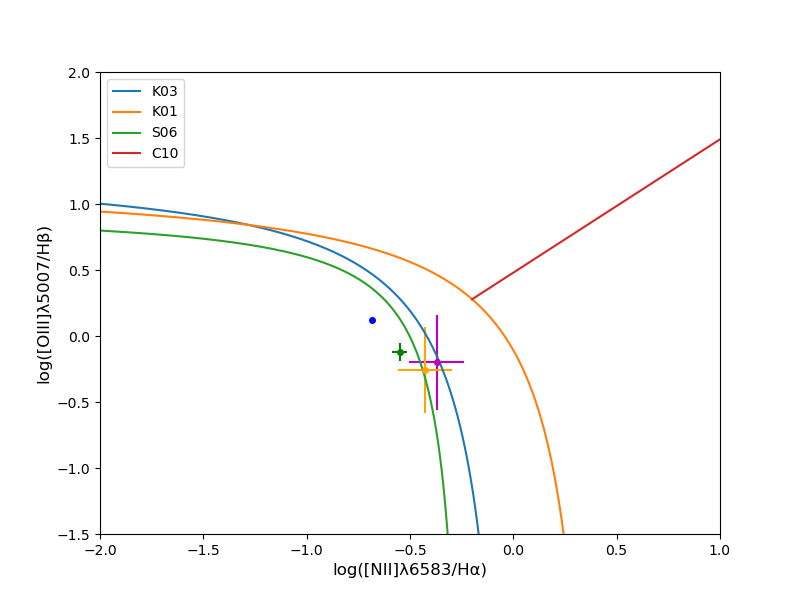

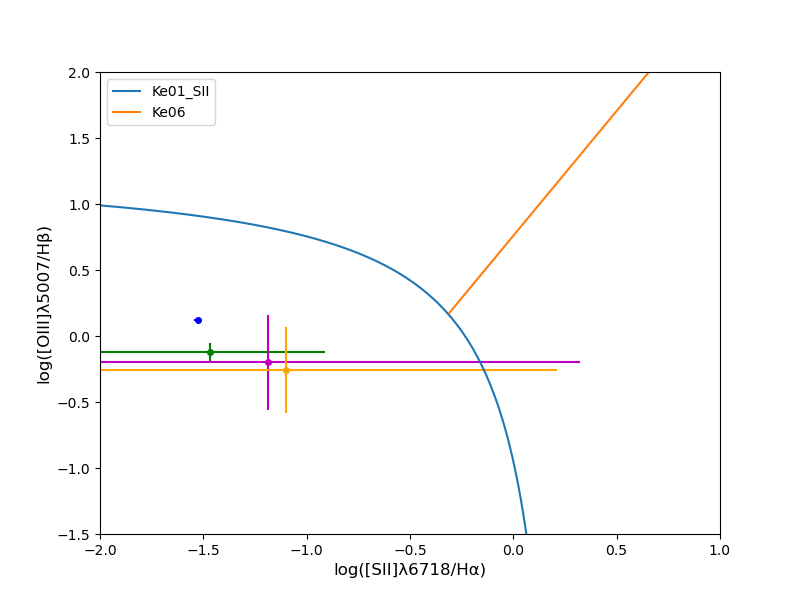

In [51]:
plt.figure(figsize=(8,6))

OIII_HB_1 = spectrum_1['Flux'][8]/spectrum_1['Flux'][1]
NII_HA_1 = spectrum_1['Flux'][12]/spectrum_1['Flux'][2]
SII_HA_1 = spectrum_1['Flux'][3]/spectrum_1['Flux'][2]
err_OIII_HB_1 = error_ratio(spectrum_1['Error_flux'][8], spectrum_1['Error_flux'][1], spectrum_1['Flux'][8], spectrum_1['Flux'][1])
err_NII_HA_1 = error_ratio(spectrum_1['Error_flux'][12], spectrum_1['Error_flux'][2], spectrum_1['Flux'][12], spectrum_1['Flux'][2])
err_SII_HA_1 = error_ratio(spectrum_1['Error_flux'][3], spectrum_1['Error_flux'][2], spectrum_1['Flux'][3], spectrum_1['Flux'][2])

OIII_HB_2 = spectrum_2['Flux'][8]/spectrum_2['Flux'][1]
NII_HA_2 = spectrum_2['Flux'][12]/spectrum_2['Flux'][2]
SII_HA_2 = spectrum_2['Flux'][3]/spectrum_2['Flux'][2]
err_OIII_HB_2 = error_ratio(spectrum_2['Error_flux'][8], spectrum_2['Error_flux'][1], spectrum_2['Flux'][8], spectrum_2['Flux'][1])
err_NII_HA_2 = error_ratio(spectrum_2['Error_flux'][12], spectrum_2['Error_flux'][2], spectrum_2['Flux'][12], spectrum_2['Flux'][2])
err_SII_HA_2 = error_ratio(spectrum_2['Error_flux'][3], spectrum_2['Error_flux'][2], spectrum_2['Flux'][3], spectrum_2['Flux'][2])

OIII_HB_3 = spectrum_3['Flux'][8]/spectrum_3['Flux'][1]
NII_HA_3 = spectrum_3['Flux'][12]/spectrum_3['Flux'][2]
SII_HA_3 = spectrum_3['Flux'][3]/spectrum_3['Flux'][2]
err_OIII_HB_3 = error_ratio(spectrum_3['Error_flux'][8], spectrum_3['Error_flux'][1], spectrum_3['Flux'][8], spectrum_3['Flux'][1])
err_NII_HA_3 = error_ratio(spectrum_3['Error_flux'][12], spectrum_3['Error_flux'][2], spectrum_3['Flux'][12], spectrum_3['Flux'][2])
err_SII_HA_3 = error_ratio(spectrum_3['Error_flux'][3], spectrum_3['Error_flux'][2], spectrum_3['Flux'][3], spectrum_3['Flux'][2])

OIII_HB_4 = spectrum_4['Flux'][8]/spectrum_4['Flux'][1]
NII_HA_4 = spectrum_4['Flux'][12]/spectrum_4['Flux'][2]
SII_HA_4 = spectrum_4['Flux'][3]/spectrum_4['Flux'][2]
err_OIII_HB_4 = error_ratio(spectrum_4['Error_flux'][8], spectrum_4['Error_flux'][1], spectrum_4['Flux'][8], spectrum_4['Flux'][1])
err_NII_HA_4 = error_ratio(spectrum_4['Error_flux'][12], spectrum_4['Error_flux'][2], spectrum_4['Flux'][12], spectrum_4['Flux'][2])
err_SII_HA_4 = error_ratio(spectrum_4['Error_flux'][3], spectrum_4['Error_flux'][2], spectrum_4['Flux'][3], spectrum_4['Flux'][2])

plt.errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
plt.plot(x, Ku03(x), label = 'K03')
plt.plot(x1, Ke01(x1), label = 'K01')
plt.plot(x2, S06(x2), label = 'S06')
plt.plot(x3, C10(x3), label = 'C10')
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_1s', bbox_inches='tight')

plt.figure(figsize=(8,6))

plt.errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_4), y = np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01_SII')
plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_1s', bbox_inches='tight')

## BPT con correzioni

In [52]:
areas_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Contaminations/Areas_OIII_1s.csv",
                        index_col = 0)
areas_NII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Contaminations/Areas_NII_1s.csv",
                        index_col = 0)
areas_SII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Contaminations/Areas_SII_1s.csv",
                        index_col = 0)
areas_Halpha = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Contaminations/Areas_Halpha_1s.csv",
                        index_col = 0)
areas_Hbeta = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Contaminations/Areas_Hbeta_1s.csv",
                        index_col = 0)

In [53]:
areas_Hbeta

,Peak 1,Peak 2,Peak 3,Peak 4
Blue,89.234,47.942,1.134,0.829
Green,8.482,45.046,1.645,1.085
Purple,1.997,6.174,94.417,33.674
Orange,0.287,0.838,2.803,64.411


In [54]:
areas_OIII['Peak 1'].iloc[0]

93.153

In [55]:
def true_flux(spectrum, spectrum2, spectrum3, spectrum4, area, e_1, e_2, e_3, e_4):
    riga_1 = spectrum*area['Peak 1'].iloc[0]/100
    err_1 = e_1*area['Peak 1'].iloc[0]/100
    riga_2 = spectrum2*area['Peak 2'].iloc[1]/100
    err_2 = e_2*area['Peak 2'].iloc[1]/100
    riga_3 = spectrum3*area['Peak 3'].iloc[2]/100
    err_3 = e_3*area['Peak 3'].iloc[2]/100
    riga_4 = spectrum4*area['Peak 4'].iloc[3]/100
    err_4 = e_4*area['Peak 4'].iloc[3]/100
    return riga_1, riga_2, riga_3, riga_4, err_1, err_2, err_3, err_4

In [56]:
OIII_1, OIII_2, OIII_3, OIII_4, err_OIII_1, err_OIII_2, err_OIII_3, err_OIII_4 = true_flux(spectrum_1['Flux'][8], spectrum_2['Flux'][8], 
                                                                                           spectrum_3['Flux'][8], spectrum_4['Flux'][8], areas_OIII,
                                                                                          spectrum_1['Error_flux'][8], spectrum_2['Error_flux'][8], 
                                                                                           spectrum_3['Error_flux'][8], spectrum_4['Error_flux'][8])
HB_1, HB_2, HB_3, HB_4, err_HB_1, err_HB_2, err_HB_3, err_HB_4 = true_flux(spectrum_1['Flux'][1], spectrum_2['Flux'][1], 
                                                                           spectrum_3['Flux'][1], spectrum_4['Flux'][1], areas_Hbeta,
                                                                           spectrum_1['Error_flux'][1], spectrum_2['Error_flux'][1], 
                                                                            spectrum_3['Error_flux'][1], spectrum_4['Error_flux'][1])
HA_1, HA_2, HA_3, HA_4, err_HA_1, err_HA_2, err_HA_3, err_HA_4 = true_flux(spectrum_1['Flux'][2], spectrum_2['Flux'][2],
                                                                           spectrum_3['Flux'][2], spectrum_4['Flux'][2], areas_Halpha,
                                                                           spectrum_1['Error_flux'][2], spectrum_2['Error_flux'][2], 
                                                                            spectrum_3['Error_flux'][2], spectrum_4['Error_flux'][2])
NII_1, NII_2, NII_3, NII_4, err_NII_1, err_NII_2, err_NII_3, err_NII_4 = true_flux(spectrum_1['Flux'][12], spectrum_2['Flux'][12],
                                                                                   spectrum_3['Flux'][12], spectrum_4['Flux'][12], areas_NII,
                                                                                   spectrum_1['Error_flux'][12], spectrum_2['Error_flux'][12], 
                                                                                   spectrum_3['Error_flux'][12], spectrum_4['Error_flux'][12])
SII_1, SII_2, SII_3, SII_4, err_SII_1, err_SII_2, err_SII_3, err_SII_4 = true_flux(spectrum_1['Flux'][3], spectrum_2['Flux'][3], 
                                                                                   spectrum_3['Flux'][3], spectrum_4['Flux'][3], areas_SII,
                                                                                   spectrum_1['Error_flux'][3], spectrum_2['Error_flux'][3], 
                                                                                   spectrum_3['Error_flux'][3], spectrum_4['Error_flux'][3])

0.0050325196952464854
0.0025330300850373707
0.01962925808056154
0.0687584660841946
0.03676474236858518
0.5555268688916554
0.362812044190731
0.1328813648332514
1.5101864521292812
0.3232137051417459
0.12939218371427397
1.3120073752987425


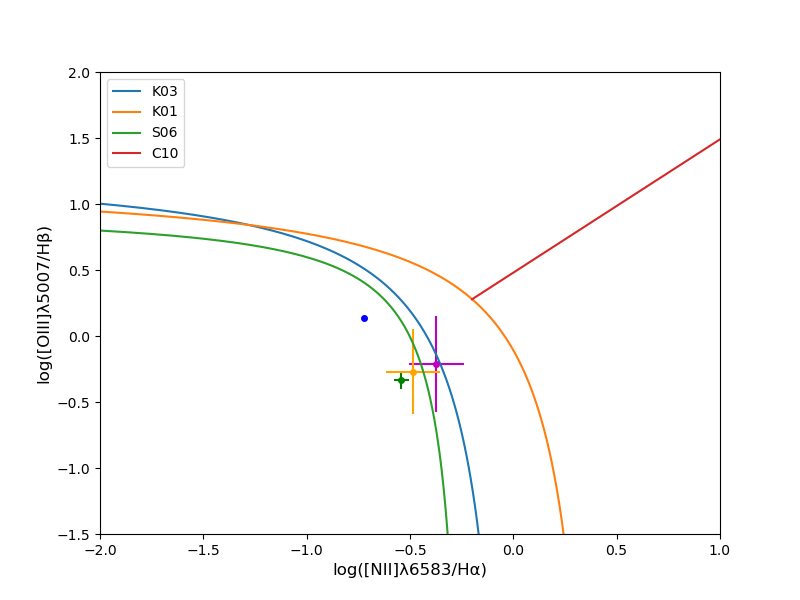

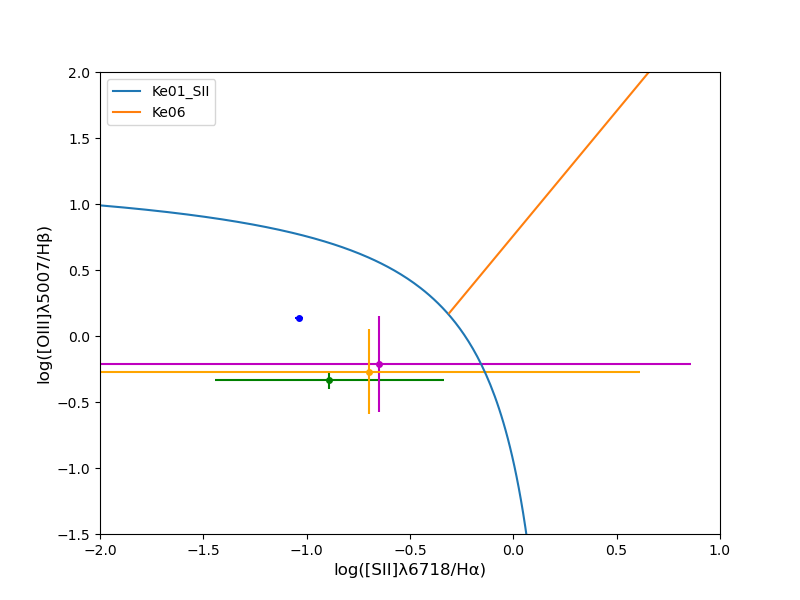

In [57]:
plt.figure(figsize=(8,6))

OIII_HB_1_true = OIII_1/HB_1
NII_HA_1_true = NII_1/HA_1
SII_HA_1_true = SII_1/HB_1
err_OIII_HB_1_true = error_ratio(err_OIII_1, err_HB_1, OIII_1, HB_1)
err_NII_HA_1_true = error_ratio(err_NII_1, err_HA_1, NII_1, HA_1)
err_SII_HA_1_true = error_ratio(err_SII_1, err_HA_1, SII_1, HA_1)

OIII_HB_2_true = OIII_2/HB_2
NII_HA_2_true = NII_2/HA_2
SII_HA_2_true = SII_2/HB_2
err_OIII_HB_2_true = error_ratio(err_OIII_2, err_HB_2, OIII_2, HB_2)
err_NII_HA_2_true = error_ratio(err_NII_2, err_HA_2, NII_2, HA_2)
err_SII_HA_2_true = error_ratio(err_SII_2, err_HA_2, SII_2, HA_2)

OIII_HB_3_true = OIII_3/HB_3
NII_HA_3_true = NII_3/HA_3
SII_HA_3_true = SII_3/HB_3
err_OIII_HB_3_true = error_ratio(err_OIII_3, err_HB_3, OIII_3, HB_3)
err_NII_HA_3_true = error_ratio(err_NII_3, err_HA_3, NII_3, HA_3)
err_SII_HA_3_true = error_ratio(err_SII_3, err_HA_3, SII_3, HA_3)

OIII_HB_4_true = OIII_4/HB_4
NII_HA_4_true = NII_4/HA_4
SII_HA_4_true = SII_4/HB_4
err_OIII_HB_4_true = error_ratio(err_OIII_4, err_HB_4, OIII_4, HB_4)
err_NII_HA_4_true = error_ratio(err_NII_4, err_HA_4, NII_4, HA_4)
err_SII_HA_4_true = error_ratio(err_SII_4, err_HA_4, SII_4, HA_4)

plt.errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
plt.plot(x, Ku03(x), label = 'K03')
plt.plot(x1, Ke01(x1), label = 'K01')
plt.plot(x2, S06(x2), label = 'S06')
plt.plot(x3, C10(x3), label = 'C10')
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_1s_true', bbox_inches='tight')

plt.figure(figsize=(8,6))

plt.errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01_SII')
plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_1s_true', bbox_inches='tight')

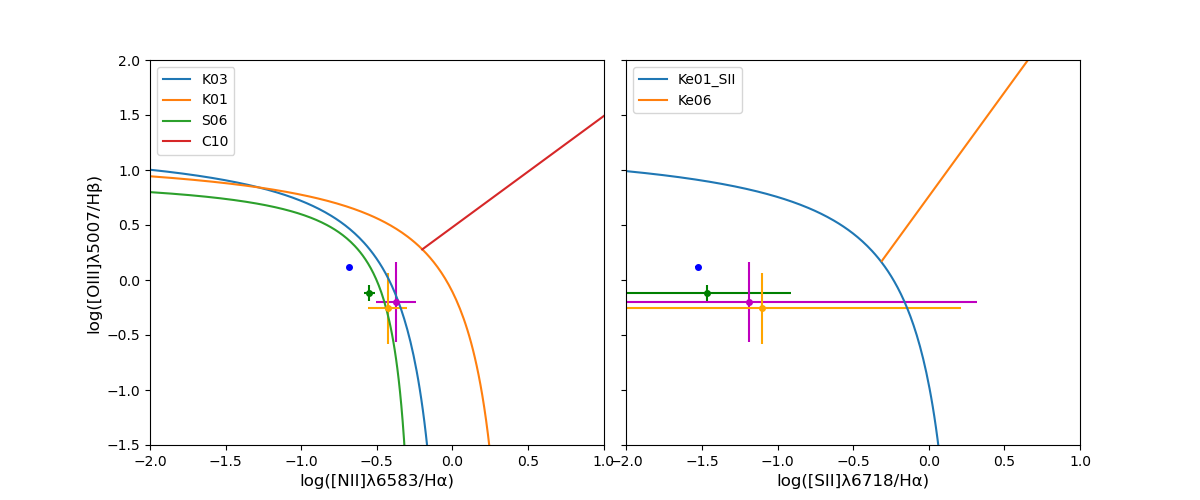

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'K03')
ax[0].plot(x1, Ke01(x1), label = 'K01')
ax[0].plot(x2, S06(x2), label = 'S06')
ax[0].plot(x3, C10(x3), label = 'C10')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1), y =np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2), y =np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3), y =np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_4), y =np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_1s_both.png', bbox_inches='tight')

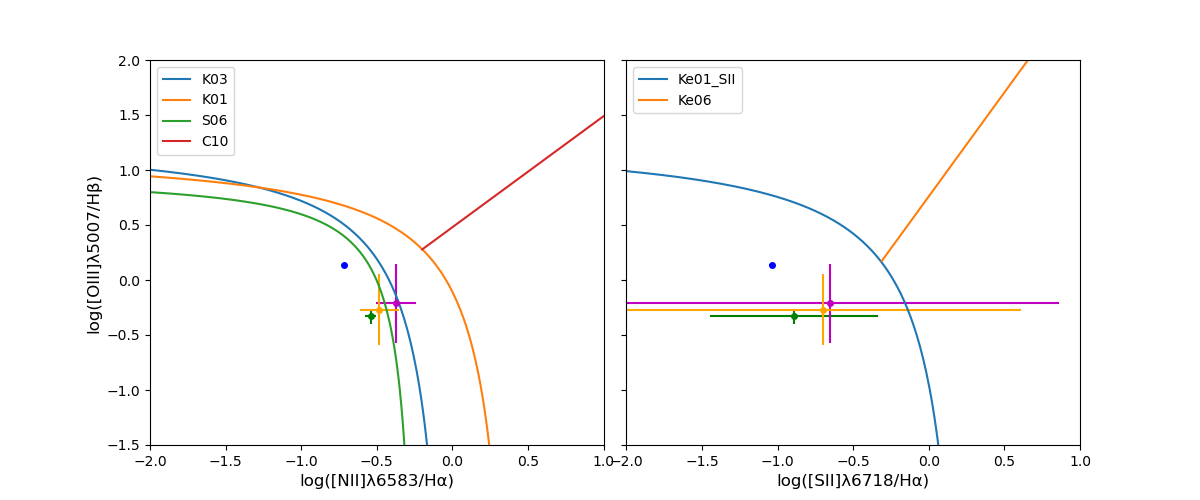

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'K03')
ax[0].plot(x1, Ke01(x1), label = 'K01')
ax[0].plot(x2, S06(x2), label = 'S06')
ax[0].plot(x3, C10(x3), label = 'C10')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_1s_both_true.png', bbox_inches='tight')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15376\1391626529.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)


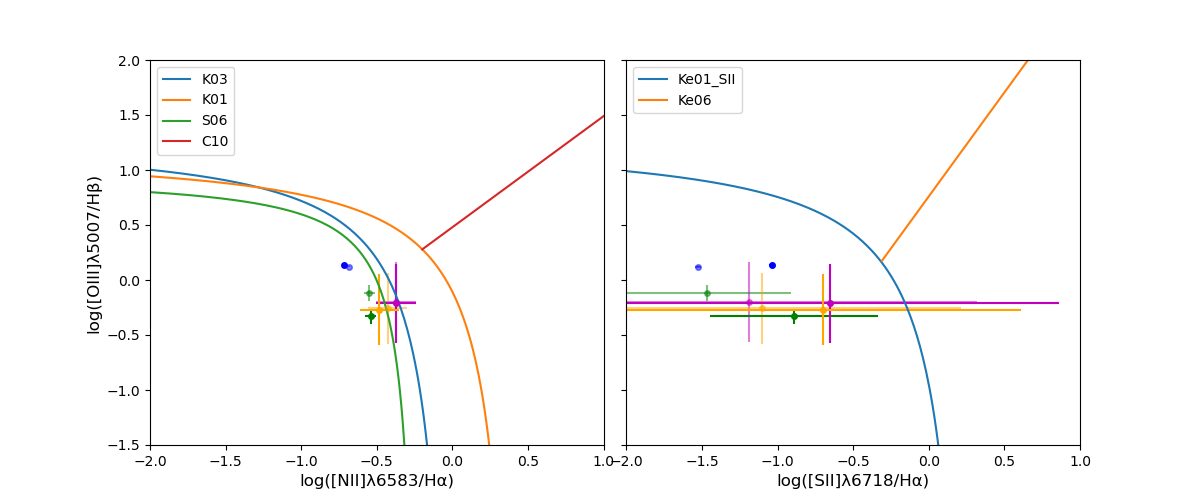

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o', alpha = 0.5)
ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.5)
ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.5)
ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.5)
ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'K03')
ax[0].plot(x1, Ke01(x1), label = 'K01')
ax[0].plot(x2, S06(x2), label = 'S06')
ax[0].plot(x3, C10(x3), label = 'C10')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1), y =np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o', alpha = 0.5)
ax[1].errorbar(x = np.log10(SII_HA_2), y =np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.5)
ax[1].errorbar(x = np.log10(SII_HA_3), y =np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.5)
ax[1].errorbar(x = np.log10(SII_HA_4), y =np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.5)
ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_1s_motion.png', bbox_inches='tight')

In [61]:
err_SII_HA_4_true

1.3120073752987425

In [62]:
err_SII_HA_4

1.3120073752987422

In [63]:
OIII_1

12.147977841025716

In [64]:
err_OIII_1

0.0856496479012497

In [65]:
error_ratio(spectrum_4['Error_flux'][8], spectrum_4['Error_flux'][1], spectrum_4['Flux'][8], spectrum_4['Flux'][1])

0.3232137051417459


0.3232137051417459

In [66]:
error_ratio(err_OIII_4, err_HB_4, OIII_4, HB_4)

0.3232137051417459


0.3232137051417459